In [1]:
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)

from sklearn.model_selection import train_test_split

from imblearn.over_sampling import SMOTE

In [2]:
df1 = pd.read_csv('Data.csv')

In [3]:
df1.head()
len(df1)
df1['Cancelled'].value_counts()

Cancelled
0    127960
1     12614
Name: count, dtype: int64

In [4]:
print('Did Not Cancel', round(df1['Cancelled'].value_counts()[0]/len(df1) * 100, 2), '% of the dataset')
print('Cancelled', round(df1['Cancelled'].value_counts()[1]/len(df1) * 100, 2), '% of the dataset')

Did Not Cancel 91.03 % of the dataset
Cancelled 8.97 % of the dataset


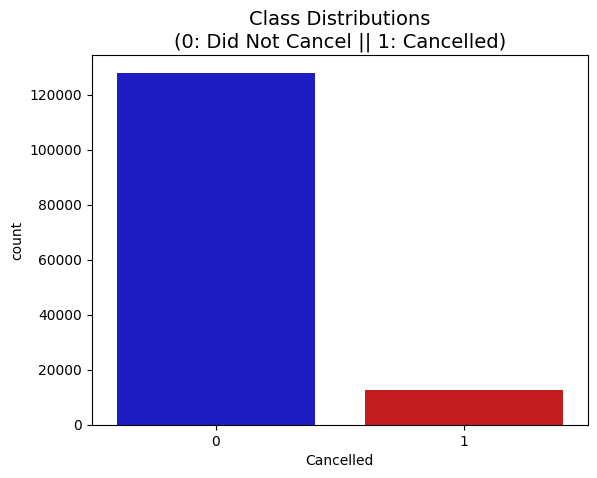

In [6]:
colors = ["#0101DF", "#DF0101"]

sns.countplot(
    x='Cancelled',
    hue='Cancelled',
    data=df1,
    palette=colors,
    legend=False
)

plt.title(
    'Class Distributions\n(0: Did Not Cancel || 1: Cancelled)',
    fontsize=14
)

plt.show()

In [7]:
df1.describe()

,Cancelled,Default_Charge,Late_Charge,NSF_Charge,Premium,Down,AmtFin,FinChg,APR,Term,...,Agent_RegisteredForCancelListReport,Agent_RegisteredForEimpendingReport,Agent_RecurringACHForm,Agent_EnrolledInCreditProgram,Agent_DownPaymentViaCC,Agent_DownPaymentViaACH,Borrower_RegisteredOnWeb,Borrower_RegisteredForEForms,Borrower_RegisteredForCancellationWarning,RecurringACH_TF
count,140574.000000,140574.000000,140574.000000,140574.000000,1.405740e+05,1.405740e+05,1.405740e+05,140574.000000,140574.000000,140574.000000,...,140571.000000,140571.000000,140574.000000,140574.000000,140574.000000,140574.000000,140574.000000,140574.000000,140574.000000,140574.000000
mean,0.089732,1.215829,116.388307,1.358726,2.337954e+04,4.597269e+03,1.878227e+04,566.019102,12.300290,9.478140,...,0.116283,0.368696,0.891068,0.799721,0.446875,0.446875,0.260745,0.309282,0.716278,0.008913
std,0.285799,5.881879,722.781218,9.103166,1.206823e+05,2.687509e+04,1.004232e+05,1813.595968,4.533707,1.440692,...,0.320565,0.482453,0.311555,0.400210,0.497171,0.497171,0.439043,0.462199,0.450805,0.093990
min,0.000000,0.000000,-110.600000,0.000000,2.050000e+02,0.000000e+00,3.395000e+01,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,2.138000e+03,4.777000e+02,1.599102e+03,103.610000,8.750000,9.000000,...,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,5.071000e+03,1.108305e+03,3.912495e+03,216.380000,12.250000,10.000000,...,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,0.000000,0.000000,49.460000,0.000000,1.442089e+04,3.000000e+03,1.129574e+04,476.665000,15.350000,10.000000,...,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
max,1.000000,635.770000,72686.200000,1350.000000,1.486929e+07,2.650548e+06,1.361670e+07,176458.560000,41.000000,36.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [8]:
df1.dtypes

Cancelled                                          int64
Loan_Num                                          object
Accepted_Date                                     object
Default_Charge                                   float64
Late_Charge                                      float64
NSF_Charge                                       float64
Premium                                          float64
Down                                             float64
AmtFin                                           float64
FinChg                                           float64
APR                                              float64
Term                                               int64
Mature_Date                                       object
Payments_Rcvd                                      int64
Agent_ID                                           int64
Borrower_ID                                        int64
Borrower_State                                    object
Borrower_Zip                   

In [9]:
df1.isnull().sum()

Cancelled                                             0
Loan_Num                                              0
Accepted_Date                                         0
Default_Charge                                        0
Late_Charge                                           0
NSF_Charge                                            0
Premium                                               0
Down                                                  0
AmtFin                                                0
FinChg                                                0
APR                                                   0
Term                                                  0
Mature_Date                                           0
Payments_Rcvd                                         0
Agent_ID                                              0
Borrower_ID                                           0
Borrower_State                                        0
Borrower_Zip                                    

In [10]:
df = df1[
    [
        "Cancelled",
        "APR",
        "Term",
        "Premium",
        "Down",
        "AmtFin",
        "FinChg",
        "Payments_Rcvd",
        "Borrower_Classification",
        "Borrower_State",
        "Borrower_RegisteredForCancellationWarning",
        "Borrower_CreditScore",
        "RecurringACH_TF",
    ]
].copy()

df["Borrower_CreditScore"] = pd.to_numeric(
    df["Borrower_CreditScore"],
    errors="coerce"
)

df["Borrower_CreditScore"] = df["Borrower_CreditScore"].fillna(
    df["Borrower_CreditScore"].median()
)

df.head()

,Cancelled,APR,Term,Premium,Down,AmtFin,FinChg,Payments_Rcvd,Borrower_Classification,Borrower_State,Borrower_RegisteredForCancellationWarning,Borrower_CreditScore,RecurringACH_TF
0,0,19.95,9,2078.00,737.00,1341.00,113.94,9,Services,CA,1,2.0,0
1,0,10.65,10,12033.18,3167.00,8866.18,438.52,10,Real Estate,TX,1,2.0,0
2,0,14.00,10,13650.94,3655.73,9995.21,652.49,10,Transportation,TX,1,2.0,0
3,0,14.50,9,8782.00,2533.00,6249.00,383.55,9,General,NC,0,2.0,0
4,0,23.95,9,1259.00,427.25,831.75,85.17,9,Construction,TX,1,2.0,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140574 entries, 0 to 140573
Data columns (total 13 columns):
 #   Column                                     Non-Null Count   Dtype  
---  ------                                     --------------   -----  
 0   Cancelled                                  140574 non-null  int64  
 1   APR                                        140574 non-null  float64
 2   Term                                       140574 non-null  int64  
 3   Premium                                    140574 non-null  float64
 4   Down                                       140574 non-null  float64
 5   AmtFin                                     140574 non-null  float64
 6   FinChg                                     140574 non-null  float64
 7   Payments_Rcvd                              140574 non-null  int64  
 8   Borrower_Classification                    140574 non-null  object 
 9   Borrower_State                             140574 non-null  object 
 10  Borrower

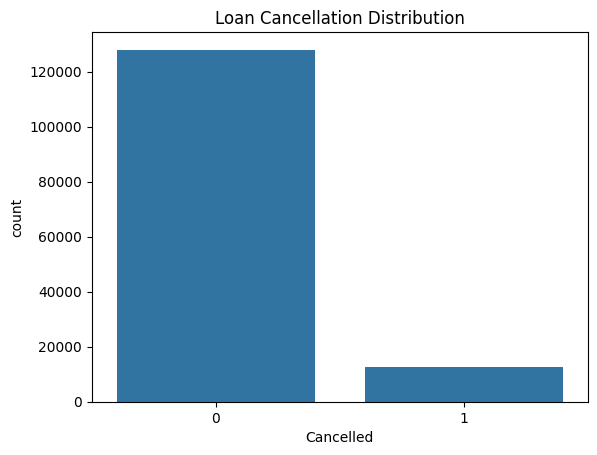

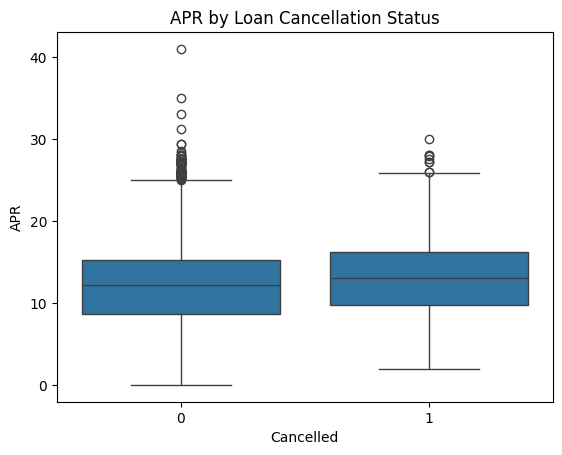

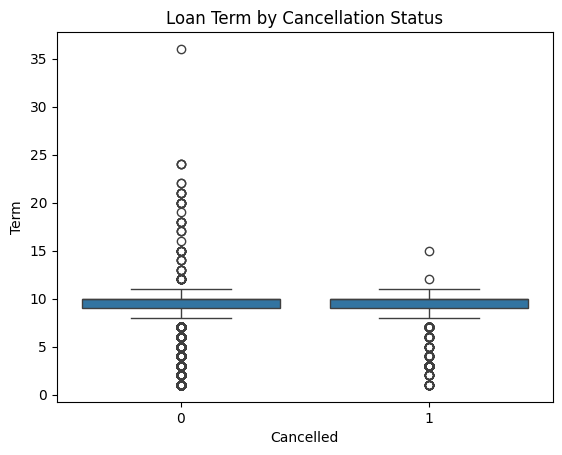

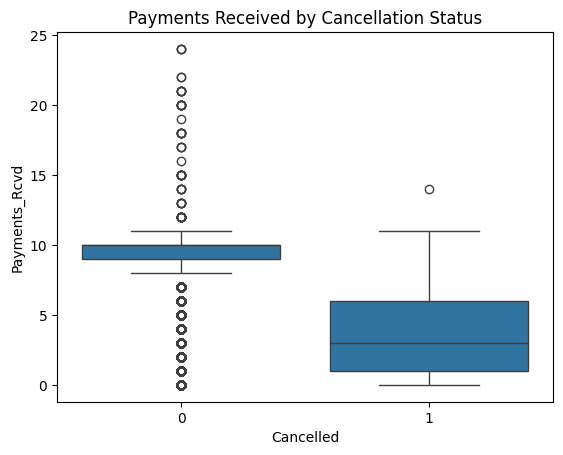

In [11]:
df.head()
df.info()
df.describe()

# Target variable distribution
df["Cancelled"].value_counts()
df["Cancelled"].value_counts(normalize=True) * 100

sns.countplot(x="Cancelled", data=df)
plt.title("Loan Cancellation Distribution")
plt.show()

# Compare APR by cancellation status
sns.boxplot(x="Cancelled", y="APR", data=df)
plt.title("APR by Loan Cancellation Status")
plt.show()

# Compare loan term by cancellation status
sns.boxplot(x="Cancelled", y="Term", data=df)
plt.title("Loan Term by Cancellation Status")
plt.show()

# Compare payments received by cancellation status
sns.boxplot(x="Cancelled", y="Payments_Rcvd", data=df)
plt.title("Payments Received by Cancellation Status")
plt.show()


In [12]:
numeric_df = pd.get_dummies(df, drop_first=True)

corr = numeric_df.corr()

print(
    corr["Cancelled"]
    .sort_values(ascending=False)
)

Cancelled                                    1.000000
Borrower_Classification_Transportation       0.084080
APR                                          0.063300
Borrower_CreditScore                         0.050211
Borrower_State_MS                            0.035623
                                               ...   
Borrower_State_GA                           -0.026835
Borrower_Classification_Real Estate         -0.034308
Borrower_Classification_Services            -0.063763
Borrower_RegisteredForCancellationWarning   -0.092932
Payments_Rcvd                               -0.543566
Name: Cancelled, Length: 77, dtype: float64


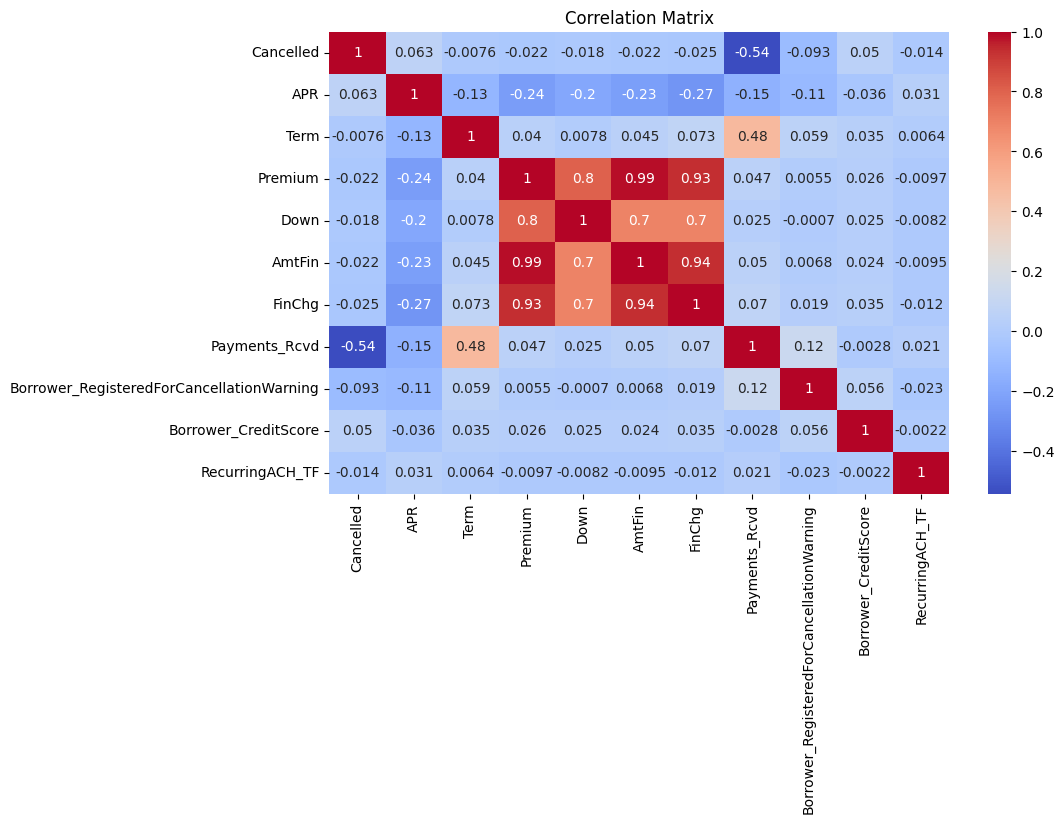

Cancelled                                    1.000000
APR                                          0.063300
Borrower_CreditScore                         0.050211
Term                                        -0.007641
RecurringACH_TF                             -0.014416
Down                                        -0.017743
AmtFin                                      -0.021626
Premium                                     -0.021947
FinChg                                      -0.025084
Borrower_RegisteredForCancellationWarning   -0.092932
Payments_Rcvd                               -0.543566
Name: Cancelled, dtype: float64

In [13]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

correlation_matrix["Cancelled"].sort_values(ascending=False)

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Convert categorical variables into numeric columns
model_df = pd.get_dummies(df, drop_first=True)

# Separate features and target
X = model_df.drop("Cancelled", axis=1)
y = model_df["Cancelled"]

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

In [16]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Cancelled
0    95970
1     9460
Name: count, dtype: int64

After SMOTE:
Cancelled
0    95970
1    95970
Name: count, dtype: int64


In [17]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train_smote, y_train_smote)

# Standard predictions
y_pred = rf_model.predict(X_test)

# Probability predictions
y_prob = rf_model.predict_proba(X_test)[:, 1]

# Classification threshold
threshold = 0.15

# Adjusted predictions
y_pred_adjusted = (y_prob >= threshold).astype(int)

In [18]:
accuracy = accuracy_score(y_test, y_pred_adjusted)
recall = recall_score(y_test, y_pred_adjusted)
precision = precision_score(y_test, y_pred_adjusted)
f1 = f1_score(y_test, y_pred_adjusted)

print("Model Performance")
print("-----------------")
print(f"Accuracy:  {accuracy:.2%}")
print(f"Recall:    {recall:.2%}")
print(f"Precision: {precision:.2%}")
print(f"F1 Score:  {f1:.2%}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_adjusted))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_adjusted))

Model Performance
-----------------
Accuracy:  88.64%
Recall:    97.27%
Precision: 43.99%
F1 Score:  60.58%

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.88      0.93     31990
           1       0.44      0.97      0.61      3154

    accuracy                           0.89     35144
   macro avg       0.72      0.93      0.77     35144
weighted avg       0.95      0.89      0.90     35144


Confusion Matrix:
[[28083  3907]
 [   86  3068]]


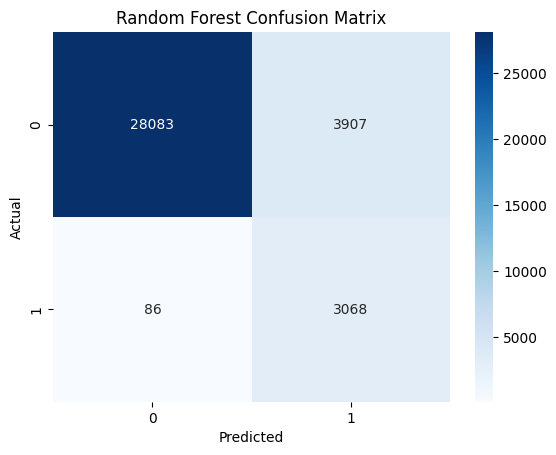

In [19]:
cm = confusion_matrix(y_test, y_pred_adjusted)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

                                      Feature  Importance
6                               Payments_Rcvd    0.527327
7   Borrower_RegisteredForCancellationWarning    0.051227
8                        Borrower_CreditScore    0.043890
1                                        Term    0.043456
67                          Borrower_State_TX    0.036619
2                                     Premium    0.029770
4                                      AmtFin    0.029427
0                                         APR    0.029185
18     Borrower_Classification_Transportation    0.028957
3                                        Down    0.028402


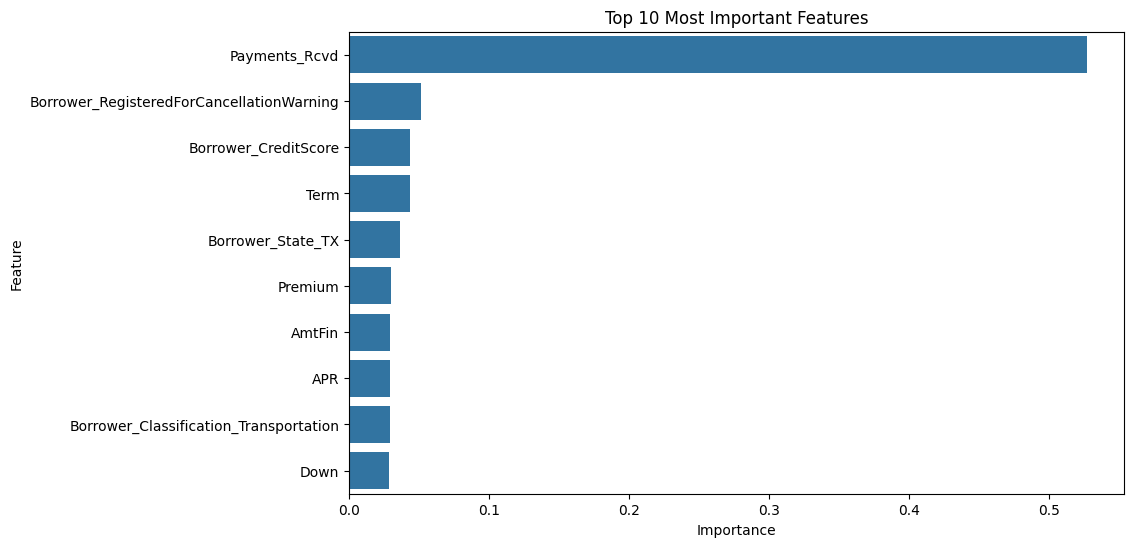

In [20]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(feature_importance.head(10))

plt.figure(figsize=(10, 6))
sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance.head(10)
)
plt.title("Top 10 Most Important Features")
plt.show()
